# Postprocessing a topology optimized multiplexer with contour optimization
Topology optimization in pixel space is very flexible, but the resulting stair step masks
are not directly fabricable.<br>
Once we approximate those masks with polygons, some optical performance is usually lost.
A contour based shape optimization step can recover part of that loss while producing a
smoother geometry.<br>
Here we start from a topology optimized wavelength division multiplexer from
[our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/),
inspect how the geometry conversion changes the device, and then optimize the contour
representation directly.

The contour finetuning workflow has four stages: we start from the binarized pixel design,
convert that mask into polygon rings, smooth the stair step contour into a more fabricable
shape, and then run gradient based contour optimization on the polygon vertices while
keeping the topology and frame boundaries fixed.

<img src="img/adjoint_32.png" width=500 alt="Placeholder schematic for contour-based postprocessing of a wavelength division multiplexer">


First, we import all required packages for this demo.

In [ ]:
from __future__ import annotations

import tempfile
from pathlib import Path

import autograd.numpy as anp
import gdstk
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.autograd import (
    smooth_min,
    value_and_grad,
)
from tidy3d.plugins.autograd.invdes.penalties import bezier_curvature
from tidy3d.plugins.invdes import PolySlabSet, curvature_penalty

## Setup
First we set up our basic simulation like in [our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/).
We have an input waveguide connected to a square design region, which has `n=4` output
waveguides.<br>
The square design region is a custom medium with a pixelated permittivity grid that we
wish to optimize such that input light of different wavelengths get directed to different
output ports.<br>
As this is a SOI device, we typically define the design region and waveguides as Silicon
sitting on an SiO2 substrate. For this demo, we make a 2D simulation, but it can be
easily made 3D by changing the `Lz` parameter, adding dimension to the structures, and
adding a substrate.

In [160]:
# material information
n_si = 3.49
n_sio2 = 1.45  # not used in 2D
n_air = 1
eps_si = n_si**2

# channel wavelengths
wvls_design = np.array([1.270, 1.290, 1.310, 1.330])

freqs_design = td.C_0 / wvls_design
freqs_design_monitor = np.sort(freqs_design)
num_freqs_design = len(freqs_design)
freq_max = np.max(freqs_design)
freq_min = np.min(freqs_design)
keys = [str(i) for i in range(num_freqs_design)]
df_design = abs(np.mean(np.diff(freqs_design)))

# forward source
freq0 = np.mean(freqs_design)
wvl0 = td.C_0 / freq0
fwidth = freq_max - freq_min
run_time = 200 / fwidth

# we average the metrics over the channels with some frequency width
channel_fwidth = df_design / 2.0
channel_bounds = [(f - channel_fwidth / 2, f + channel_fwidth / 2) for f in freqs_design]
num_freqs_channel = 5
channel_freqs = []
for fmin, fmax in channel_bounds:
    sub_freqs = np.linspace(fmin, fmax, num_freqs_channel)
    channel_freqs += sub_freqs.tolist()
# Monitor frequency coordinates must be strictly monotone for interpolation.
channel_freqs = np.sort(np.asarray(channel_freqs, dtype=float))

# size of design region
lx = 4.5
ly = 4.5
ly_single = ly / num_freqs_design
lz = td.inf

# size of waveguides
wg_width = 0.3
wg_length = 1.5
wg_spacing = 0.8

# spacing between design region and PML in y
buffer = 1.5

# size of simulation
Lx = lx + wg_length * 2
Ly = ly + buffer * 2
Lz = 0.0

# fabrication constraints from the original pixel optimization setup
radius = 0.100
beta0 = 2

# resolution information
min_steps_per_wvl = 18
dl_design_region = 0.015
nx = int(lx / dl_design_region)
ny = int(ly / dl_design_region)

# design region and threshold settings
design_region_geo = td.Box(size=(lx, ly, lz), center=(0, 0, 0))
design_region_geometry = design_region_geo
slab_bounds = (-float("inf"), float("inf"))
permittivity_threshold = float((eps_si + 1.0) / 2.0)

core_medium = td.Medium(permittivity=eps_si)
background_medium = td.Medium(permittivity=n_air**2)

### Static Simulation
First, we'll define the simulation without any design region using the "static"
components that don't change over the optimization.<br>
We use `mode_index=0` for the source and the mode monitors, following the mode
identification in [our reference notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd9WDM/).

In [161]:
# define the waveguide ports
wg_in = td.Structure(
    geometry=td.Box(
        center=(-Lx / 2, 0, 0),
        size=(wg_length * 2, wg_width, lz),
    ),
    medium=td.Medium(permittivity=n_si**2),
)

centers_y = np.linspace(-ly / 2.0 + ly_single / 2.0, +ly / 2.0 - ly_single / 2.0, num_freqs_design)
mode_size = (0, 0.9 * ly_single, td.inf)
mode_spec = td.ModeSpec()

wgs_out = []
for center_y in centers_y:
    wg_out = td.Structure(
        geometry=td.Box(
            center=(+Lx / 2, center_y, 0),
            size=(wg_length * 2, wg_width, lz),
        ),
        medium=td.Medium(permittivity=n_si**2),
    )
    wgs_out.append(wg_out)

# measure the mode amplitudes at each of the output ports
mnts_mode = []
for key, center_y in zip(keys, centers_y):
    mnt_mode = td.ModeMonitor(
        center=(Lx / 2 - wg_length / 2, center_y, 0),
        size=mode_size,
        freqs=channel_freqs,
        mode_spec=td.ModeSpec(),
        name=f"mode_{key}",
    )
    mnts_mode.append(mnt_mode)

# measures the flux at each of the output ports
mnts_flux = []
for key, center_y in zip(keys, centers_y):
    mnt_flux = td.FluxMonitor(
        center=(Lx / 2 - wg_length / 2, center_y, 0),
        size=mode_size,
        freqs=channel_freqs,
        name=f"flux_{key}",
    )
    mnts_flux.append(mnt_flux)

# and a field monitor that measures fields on the z=0 plane at the design freqs
fld_mnt = td.FieldMonitor(
    center=(0, 0, 0),
    size=(td.inf, td.inf, 0),
    freqs=freqs_design_monitor,
    name="field",
)

# inject the fundamental mode into the input waveguide
mode_src = td.ModeSource(
    center=(-Lx / 2 + wg_length / 2, 0, 0),
    size=mode_size,
    source_time=td.GaussianPulse(
        freq0=freq0,
        fwidth=fwidth,
    ),
    direction="+",
    mode_index=0,
)

sim_static = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=min_steps_per_wvl,
        wavelength=np.min(wvls_design),
    ),
    structures=[wg_in, *wgs_out],
    sources=[mode_src],
    monitors=[*mnts_mode, *mnts_flux, fld_mnt],
    boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=True if Lz else False),
    run_time=run_time,
)

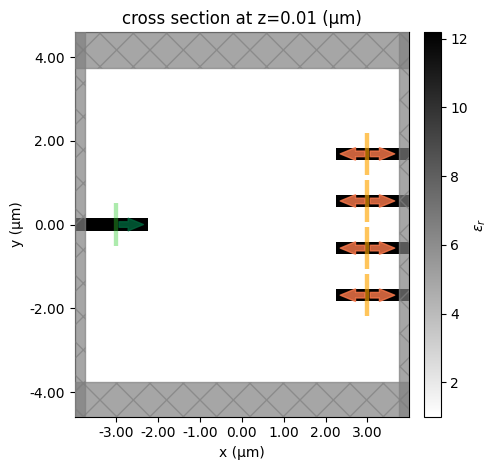

In [162]:
ax = sim_static.plot_eps(z=0.01)
ax.set_aspect("equal")

## Baseline Helpers
The next few cells compare the saved pixel result against the GDS converted version and a smoothed contour based geometry
representations.

### Build Design Structures
These two helpers are used whenever we switch representation (pixel, GDS export/import, contour).
They keep the simulation assembly cell clean by returning ready to attach structures.

In [163]:
def make_custom_design_structure(density, name):
    density_arr = np.asarray(density, dtype=float).squeeze()
    if density_arr.ndim != 2:
        raise ValueError(
            f"Expected a 2D density array after squeeze, got shape {density_arr.shape}."
        )
    eps_data = (1.0 + (eps_si - 1.0) * density_arr)[:, :, np.newaxis]
    xs = np.linspace(-lx / 2, lx / 2, density_arr.shape[0])
    ys = np.linspace(-ly / 2, ly / 2, density_arr.shape[1])
    eps_arr = td.SpatialDataArray(
        data=eps_data,
        coords={"x": xs, "y": ys, "z": [0.0]},
    )
    medium = td.CustomMedium(permittivity=eps_arr)
    return td.Structure(geometry=design_region_geo, medium=medium, name=name)

### Build Simulations for the Current Design
With the static simulation fully defined, we can write a small function that swaps in the
current design representation and chooses the monitor set we need for the next computation.
This keeps all later comparisons on the same simulation footprint and design region mesh.

In [164]:
def make_sim_with_design(design_region, freqs_mode_flux, include_field):
    mnts_mode = [
        td.ModeMonitor(
            center=(Lx / 2 - wg_length / 2, float(center_y), 0.0),
            size=mode_size,
            freqs=freqs_mode_flux,
            mode_spec=mode_spec,
            name=f"mode_{key}",
        )
        for key, center_y in zip(keys, centers_y)
    ]

    mnts_flux = [
        td.FluxMonitor(
            center=(Lx / 2 - wg_length / 2, float(center_y), 0.0),
            size=mode_size,
            freqs=freqs_mode_flux,
            name=f"flux_{key}",
        )
        for key, center_y in zip(keys, centers_y)
    ]

    monitors = [*mnts_mode, *mnts_flux]
    if include_field:
        monitors.append(
            td.FieldMonitor(
                center=(0.0, 0.0, 0.0),
                size=(td.inf, td.inf, 0),
                freqs=freqs_design_monitor,
                name="field",
            )
        )

    design_structs = (
        (design_region,) if isinstance(design_region, td.Structure) else tuple(design_region)
    )
    design_override = td.MeshOverrideStructure(
        geometry=design_region_geo,
        dl=[dl_design_region, dl_design_region, dl_design_region],
    )
    grid_spec = sim_static.grid_spec.updated_copy(
        override_structures=[*sim_static.grid_spec.override_structures, design_override]
    )
    return sim_static.updated_copy(
        structures=[*sim_static.structures, *design_structs],
        grid_spec=grid_spec,
        monitors=tuple(monitors),
    )

### Defining the Transmission Metric
With our simulation fully defined as a function of the inserted design, we are ready to
define the metric that we want to compare across pixel, GDS, and contour representations.
For each output waveguide, we average the source normalized fundamental mode power over
each wavelength channel. The channel score is the desired in band power minus the average
power coupled into that same port at the other design channels, which penalizes cross talk.
The scalar transmission metric is the smooth minimum of the four channel scores, so the
weakest channel drives the comparison and contour update.<br>
This metric is computed in linear power. The logarithm is used only later when the dense
spectral flux and mode power curves are displayed in dB.


In [165]:
def average_over_channel(spectrum, fmin, fmax):
    freqs = spectrum.f
    freqs_in_channel = np.logical_and(freqs >= fmin, freqs <= fmax).values
    num_freqs = np.sum(freqs_in_channel)
    return spectrum.values @ freqs_in_channel / num_freqs


def get_power(sim_data, mnt_index, freq_index):
    mnt_data = sim_data[f"mode_{mnt_index}"]
    amp = mnt_data.amps.sel(direction="+", mode_index=0)
    power_spectrum = anp.abs(amp) ** 2
    return average_over_channel(
        spectrum=power_spectrum,
        fmin=channel_bounds[freq_index][0],
        fmax=channel_bounds[freq_index][1],
    )


def get_metric(sim_data, mnt_index):
    power_all = [
        get_power(sim_data=sim_data, mnt_index=mnt_index, freq_index=j)
        for j in range(num_freqs_design)
    ]
    power_transmitted = power_all[mnt_index]
    power_leaked = sum(power_all) - power_transmitted
    avg_power_leaked = power_leaked / float(num_freqs_design - 1)
    return power_transmitted - avg_power_leaked


def transmission_from_data(sim_data):
    metrics = [get_metric(sim_data=sim_data, mnt_index=i) for i in range(num_freqs_design)]
    return smooth_min(anp.array(metrics))


def get_transmission(design_region, task_name):
    sim = make_sim_with_design(
        design_region=design_region,
        freqs_mode_flux=channel_freqs,
        include_field=False,
    )
    data = web.run(sim, task_name=task_name, verbose=False)
    return transmission_from_data(data)

### Export to GDS and Load It Back
We export the binarized design to GDS and load the polygons back into Tidy3D before
simulating again.

In [166]:
def gds_export_import(design_region):
    with tempfile.TemporaryDirectory(prefix="wdm_contour_gds_export_import_") as tmp:
        gds_path = Path(tmp) / "wdm_gds_export_import_pixel_exact.gds"
        design_region.to_gds_file(
            fname=str(gds_path),
            z=0.0,
            permittivity_threshold=permittivity_threshold,
            frequency=freq0,
            pixel_exact=True,
        )
        lib = gdstk.read_gds(str(gds_path))
        geometry = td.Geometry.from_gds(
            gds_cell=lib.cells[0],
            axis=2,
            slab_bounds=slab_bounds,
            gds_layer=0,
            gds_dtype=0,
        )
        return td.Structure(
            geometry=geometry, medium=core_medium, name="wdm_gds_export_import_pixel_exact"
        )

## Load Saved Pixel Design and Evaluate Baselines
We first load the saved pixel density array from the previous run, threshold it to the
pixel mask, and rebuild the corresponding custom medium.<br>
This pixel reference is used for the following conversion and contour optimization
comparisons.


[baseline transmission metric]
pixel_metric=-0.554


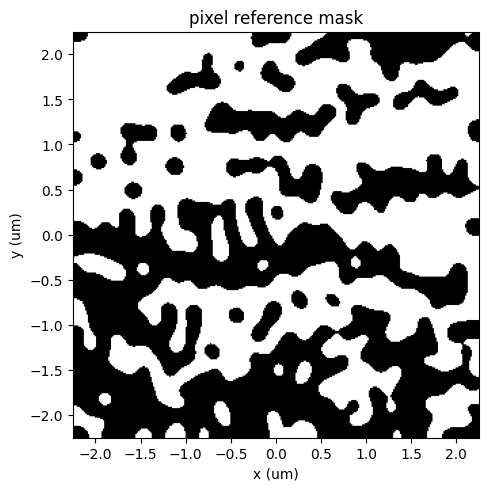

In [167]:
pixel_npy_path = Path("misc/wdm_contour_only_pixel_density.npy")

pixel_density = (np.asarray(np.load(pixel_npy_path), dtype=float) >= 0.5).astype(float)
pixel_design = make_custom_design_structure(pixel_density, name="pixel_design")

pixel_tx = get_transmission(pixel_design, task_name="wdm_pixel_baseline")

print("\n[baseline transmission metric]")
print(f"pixel_metric={pixel_tx:.3f}")

fig_pixel, ax_pixel = plt.subplots(figsize=(5.4, 4.8), constrained_layout=True)
ax_pixel.imshow(
    pixel_density.T,
    origin="lower",
    extent=(-lx / 2, lx / 2, -ly / 2, ly / 2),
    cmap="binary",
)
ax_pixel.set_title("pixel reference mask")
ax_pixel.set_aspect("equal")
ax_pixel.set_xlim(-2.25, 2.25)
ax_pixel.set_ylim(-2.25, 2.25)
ax_pixel.set_xlabel("x (um)")
ax_pixel.set_ylabel("y (um)")
plt.show()

## GDS Export / Import Comparison
We now take the binarized mask, export it to GDS with `pixel_exact=True`, load the
polygons back, and simulate that geometry again.
This shows the extra loss caused by the export/import conversion itself.

In [168]:
gds_design = gds_export_import(pixel_design)
gds_tx = get_transmission(gds_design, task_name="wdm_gds_export_import_pixel_exact")

print("\n[gds export/import transmission]")
print(f"transmission after gds conversion: {gds_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - gds_tx:.3f}")


[gds export/import transmission]
transmission after gds conversion: -0.868
loss compared to pixel reference: 0.314


## Pixel to contour conversion
Here we call `CustomMedium.to_polyslabs(...)` to extract contour rings from the
binarized design. Very small islands and holes are removed
(`min_area=(4*dl_design_region)^2`) as they are not fabricable.<br>
The raw stair step contour follows the pixel grid too closely to be a realistic
fabrication target, so we also smooth the rings before simulation. This improves
fabricability by reducing stair step edges while still keeping the contour close to
the binarized mask.<br>
In return, we usually observe some additional loss that the contour optimization will try
to recover.

In [169]:
contour_smooth_sigma = 2.0  # smoothing strength in vertex index space

contour_raw_set = PolySlabSet.from_custom_medium(
    pixel_design.medium,
    slab_bounds=slab_bounds,
    axis=2,
    threshold=permittivity_threshold,
    pixel_exact=True,
)

contour_smooth_set = contour_raw_set.smooth(contour_smooth_sigma)

contour_raw_structures = contour_raw_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_raw",
)
contour_smooth_structures = contour_smooth_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_smooth",
)

contour_raw_tx = get_transmission(contour_raw_structures, task_name="wdm_contour_raw")
contour_smooth_tx = get_transmission(contour_smooth_structures, task_name="wdm_contour_smooth")

print("\n[contour conversion transmission]")
print(f"raw contour transmission: {contour_raw_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - contour_raw_tx:.3f}")

print(f"smooth contour transmission: {contour_smooth_tx:.3f}")
print(f"loss compared to pixel reference: {pixel_tx - contour_smooth_tx:.3f}")


[contour conversion transmission]
raw contour transmission: -0.850
loss compared to pixel reference: 0.297
smooth contour transmission: -0.870
loss compared to pixel reference: 0.316


## One time geometry check: raw vs smoothed contour
This is a before optimization geometry sanity check.<br>
Left: directly extracted contour rings from `to_polyslabs`.<br>
Right: rings after Gaussian smoothing.<br>
We zoom to the design frame (`x,y in [-2.25, 2.25]`) to focus on the relevant region.

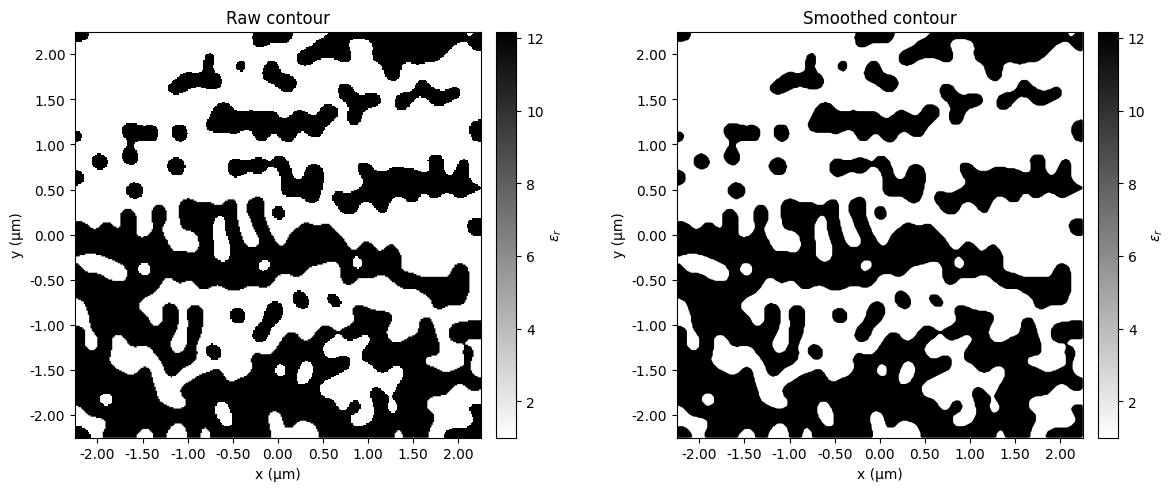

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

sim_raw_plot = sim_static.updated_copy(
    structures=[*sim_static.structures, *contour_raw_structures], monitors=[]
)
sim_smooth_plot = sim_static.updated_copy(
    structures=[*sim_static.structures, *contour_smooth_structures], monitors=[]
)

sim_raw_plot.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=axes[0])
axes[0].set_title("Raw contour")
axes[0].set_xlim(-2.25, 2.25)
axes[0].set_ylim(-2.25, 2.25)
axes[0].set_aspect("equal")

sim_smooth_plot.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=axes[1])
axes[1].set_title("Smoothed contour")
axes[1].set_xlim(-2.25, 2.25)
axes[1].set_ylim(-2.25, 2.25)
axes[1].set_aspect("equal")

plt.show()

## Defining Objective Function
With the contour representation defined, we are ready to construct the objective used for
the shape optimization stage.<br>
The main optical term is the transmission metric measured
from the four output waveguides.<br>
We then subtract a curvature penalty so the smoothed contour remains easier to fabricate.

### Curvature Penalty
The curvature term is evaluated on the smoothed contour set and penalizes local regions
whose curvature radius falls below the chosen fabrication threshold.

In [171]:
curvature_penalty_weight = 10.0  # overall penalty weight in the contour objective
curvature_penalty_alpha = 1.0  # scale inside the threshold power curvature penalty
curvature_penalty_exponent = 2.0  # how sharply violations below the radius threshold grow
curvature_penalty_eps = 1e-6  # numerical floor used when converting curvature to radius


def make_threshold_power_curvature_penalty(threshold_radius, alpha, exponent, eps):
    def ring_penalty(points):
        xs, ys = points.T
        curvature = bezier_curvature(xs, ys)
        curvature_radius = 1.0 / (anp.abs(curvature) + eps)
        margin = anp.maximum(threshold_radius - curvature_radius, 0.0)
        return anp.mean(alpha * (margin**exponent))

    return ring_penalty

### Map Optimizer Parameters to Valid Contours
The contour optimizer works directly in flattened vertex coordinates. The plugin handles
frame boundary freezing and bounds clipping for the strict contour mapping, while
safe against self intersections updates are reserved for optimizer step acceptance.

## Contour Optimization
We are now ready to optimize the contour geometry.
We optimize the smoothed contour directly in flattened vertex coordinates. The accepted
The accepted contour set remains the optimization state, while updates that avoid self intersections are
used only when accepting optimizer steps.<br>
The contour update uses a plain SGD step.

In [172]:
contour_opt_steps = 30  # number of contour optimization steps
contour_opt_lr = 0.004  # optimizer learning rate

curvature_penalty_fn = make_threshold_power_curvature_penalty(
    threshold_radius=0.100,
    alpha=curvature_penalty_alpha,
    exponent=curvature_penalty_exponent,
    eps=curvature_penalty_eps,
)

contour_current_set = contour_smooth_set
flat_reference = np.asarray(contour_current_set.flatten_ring_vertices(), dtype=float)
frame_boundary_mask = contour_current_set.frame_boundary_mask_flat(repeat_xy=True)

flat_params = flat_reference.copy()

objective_history = []
transmission_history = []
curvature_history = []
contour_structures_over_steps = []


def make_objective(contour_set_template):
    def objective(values):
        contour_set = contour_set_template.with_flat_ring_vertices(values)
        design_region = contour_set.to_structures(
            foreground_medium=core_medium,
            background_medium=background_medium,
            name_prefix="contour_opt",
        )
        tx = get_transmission(design_region=design_region, task_name="wdm_contour_opt")
        curv = curvature_penalty(
            contour_set, penalty_fn=curvature_penalty_fn, ignore_boundary_vertices=True
        )
        return tx - curvature_penalty_weight * curv

    return objective


for step in range(contour_opt_steps):
    objective = make_objective(contour_current_set)
    value_grad_fn = value_and_grad(objective)
    value, gradient = value_grad_fn(flat_params)
    gradient = np.asarray(gradient, dtype=float)
    gradient[frame_boundary_mask] = 0.0

    curv_base = float(
        curvature_penalty(
            contour_current_set,
            penalty_fn=curvature_penalty_fn,
            ignore_boundary_vertices=True,
        )
    )
    curv_term = curvature_penalty_weight * curv_base
    tx_current = float(value) + curv_term

    objective_history.append(float(value))
    transmission_history.append(tx_current)
    curvature_history.append(curv_term)
    contour_structures_over_steps.append(
        contour_current_set.to_structures(
            foreground_medium=core_medium,
            background_medium=background_medium,
            name_prefix=f"contour_step_{step + 1}",
        )
    )

    candidate = flat_params + contour_opt_lr * gradient
    candidate_set, _ = contour_current_set.safe_update(
        candidate,
        freeze_boundary=True,
        respect_bounds=True,
    )
    contour_current_set = candidate_set
    flat_params = np.asarray(contour_current_set.flatten_ring_vertices(), dtype=float)

    print(
        f"[shape] step={step + 1:02d}, "
        f"obj={float(value):.3f}, tx={tx_current:.3f}, curv={curv_term:.3f}, "
        f"grad_norm={np.linalg.norm(gradient):.3f}"
    )

contour_opt_set = contour_current_set
contour_opt_structures = contour_opt_set.to_structures(
    foreground_medium=core_medium,
    background_medium=background_medium,
    name_prefix="contour_opt_final",
)

contour_opt_tx = get_transmission(contour_opt_structures, task_name="wdm_contour_opt_final")
print(f"\noptimized contour transmission={contour_opt_tx:.3f}")

[shape] step=01, obj=-0.886, tx=-0.870, curv=0.016, grad_norm=5.553
[shape] step=02, obj=-0.776, tx=-0.761, curv=0.015, grad_norm=4.098
[shape] step=03, obj=-0.721, tx=-0.707, curv=0.014, grad_norm=2.866
[shape] step=04, obj=-0.691, tx=-0.678, curv=0.013, grad_norm=2.287
[shape] step=05, obj=-0.672, tx=-0.660, curv=0.012, grad_norm=2.012
[shape] step=06, obj=-0.656, tx=-0.645, curv=0.011, grad_norm=1.799
[shape] step=07, obj=-0.643, tx=-0.633, curv=0.010, grad_norm=1.602
[shape] step=08, obj=-0.633, tx=-0.623, curv=0.010, grad_norm=1.472
[shape] step=09, obj=-0.625, tx=-0.615, curv=0.010, grad_norm=1.380
[shape] step=10, obj=-0.618, tx=-0.608, curv=0.010, grad_norm=1.289
[shape] step=11, obj=-0.612, tx=-0.602, curv=0.010, grad_norm=1.184
[shape] step=12, obj=-0.607, tx=-0.597, curv=0.010, grad_norm=1.102
[shape] step=13, obj=-0.602, tx=-0.592, curv=0.010, grad_norm=1.022
[shape] step=14, obj=-0.598, tx=-0.588, curv=0.010, grad_norm=0.968
[shape] step=15, obj=-0.595, tx=-0.585, curv=0.0

## Visualize Results
Let's now inspect how the contour geometry and the optical response changed during the
shape optimization stage.

### Structure Evolution
Instead of relying on live redraw, we render selected snapshots after optimization:
first step, middle step, and last step.
This makes the geometry evolution easy to compare in one figure.

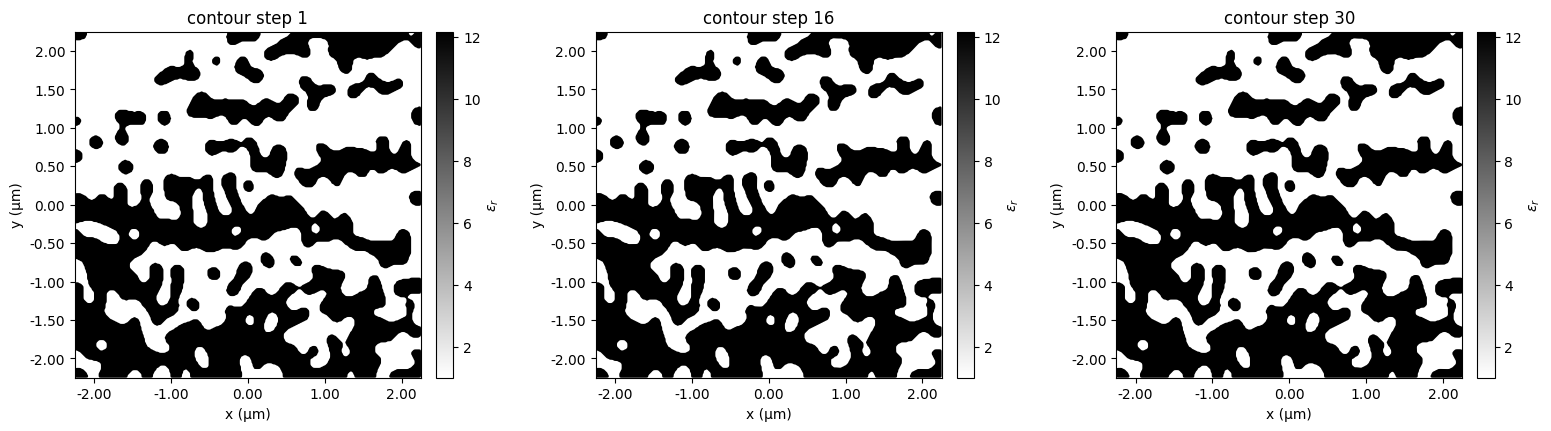

In [173]:
idx_samples = [0, len(contour_structures_over_steps) // 2, len(contour_structures_over_steps) - 1]
fig_steps, axes_steps = plt.subplots(
    1, len(idx_samples), figsize=(5.2 * len(idx_samples), 4.2), constrained_layout=True
)

for ax, idx in zip(axes_steps, idx_samples):
    step_num = idx + 1
    sim_step = sim_static.updated_copy(
        structures=[*sim_static.structures, *contour_structures_over_steps[idx]],
        monitors=[],
    )
    sim_step.plot_eps(z=0.0, monitor_alpha=0.0, source_alpha=0.0, ax=ax)
    ax.set_title(f"contour step {step_num}")
    ax.set_aspect("equal")
    ax.set_xlim(-2.25, 2.25)
    ax.set_ylim(-2.25, 2.25)

plt.show()

### Transmission vs Iteration
To separate optical recovery from the fabrication penalty, we also track the transmission
term by itself.<br>
We keep the pixel baseline and the smoothed reference contour as references.

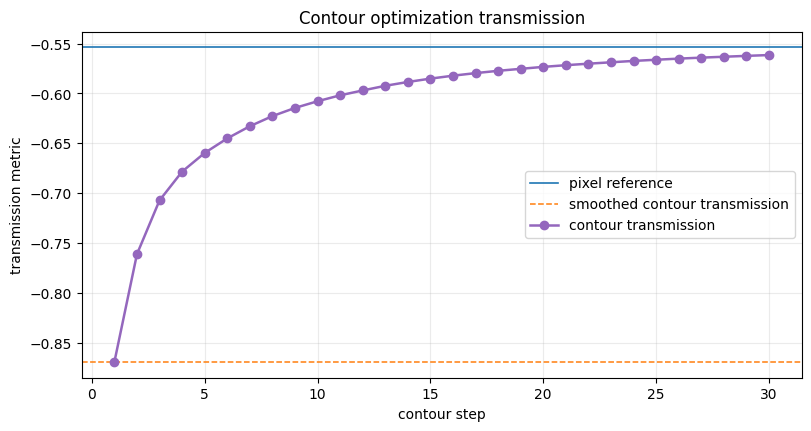

In [174]:
fig_tx, ax_tx = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
ax_tx.axhline(
    y=float(pixel_tx), color="tab:blue", linestyle="-", linewidth=1.2, label="pixel reference"
)
ax_tx.axhline(
    y=float(contour_smooth_tx),
    color="tab:orange",
    linestyle="--",
    linewidth=1.1,
    label="smoothed contour transmission",
)
ax_tx.plot(
    np.arange(1, len(transmission_history) + 1),
    transmission_history,
    marker="o",
    color="tab:purple",
    linewidth=1.8,
    label="contour transmission",
)
ax_tx.set_xlabel("contour step")
ax_tx.set_ylabel("transmission metric")
ax_tx.set_title("Contour optimization transmission")
ax_tx.grid(alpha=0.25)
ax_tx.legend(loc="best")
plt.show()

### Final Simulation
After the optimization is complete, we switch back to dense wavelength sampling so the
recovered contour can be compared against the pixel baseline and the raw contour in
more detail.

In [175]:
num_freqs_measure = 151  # dense wavelength samples for the final flux and power plots


def run_dense_eval(design_region, task_name):
    freqs_measure = np.linspace(freq_min - df_design, freq_max + df_design, num_freqs_measure)
    sim = make_sim_with_design(
        design_region=design_region, freqs_mode_flux=freqs_measure, include_field=True
    )
    sim_data = web.run(sim, task_name=task_name, verbose=False)

    wavelength_nm = None
    flux_db = []
    power_db = []

    for idx in range(num_freqs_design):
        flux_da = sim_data[f"flux_{idx}"].flux
        flux_vals = np.asarray(flux_da.values, dtype=float)
        freqs_vals = np.asarray(flux_da.f.values, dtype=float)
        wavelength_nm = 1000.0 * td.C_0 / freqs_vals
        flux_db.append(10.0 * np.log10(np.maximum(flux_vals, 1e-20)))

        amps = sim_data[f"mode_{idx}"].amps.sel(direction="+", mode_index=0)
        powers = np.abs(np.asarray(amps.values)) ** 2
        power_db.append(10.0 * np.log10(np.maximum(powers, 1e-20)))

    return {
        "sim": sim,
        "sim_data": sim_data,
        "wavelength_nm": np.asarray(wavelength_nm, dtype=float),
        "flux_db": np.asarray(flux_db, dtype=float),
        "power_db": np.asarray(power_db, dtype=float),
        "transmission": transmission_from_data(sim_data),
    }

### Dense Spectral Analysis
We now perform a dense spectral evaluation and compare the pixel reference, the smoothed
contour conversion, and the optimized contour. For each output port we plot total flux and
the power in the fundamental output mode around all channels.



[dense transmission metric]
pixel=-0.534
smoothed contour=-0.855
optimized contour=-0.545


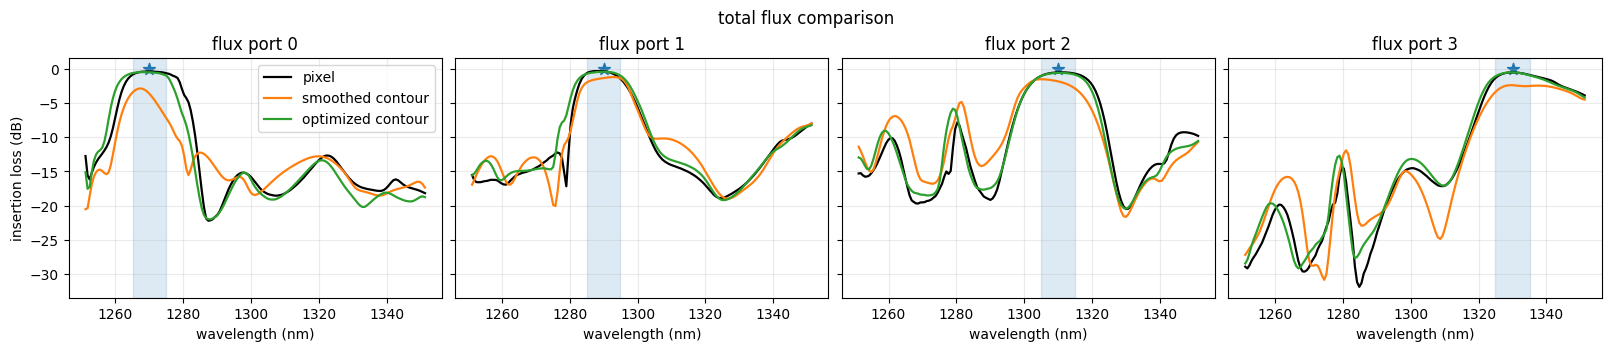

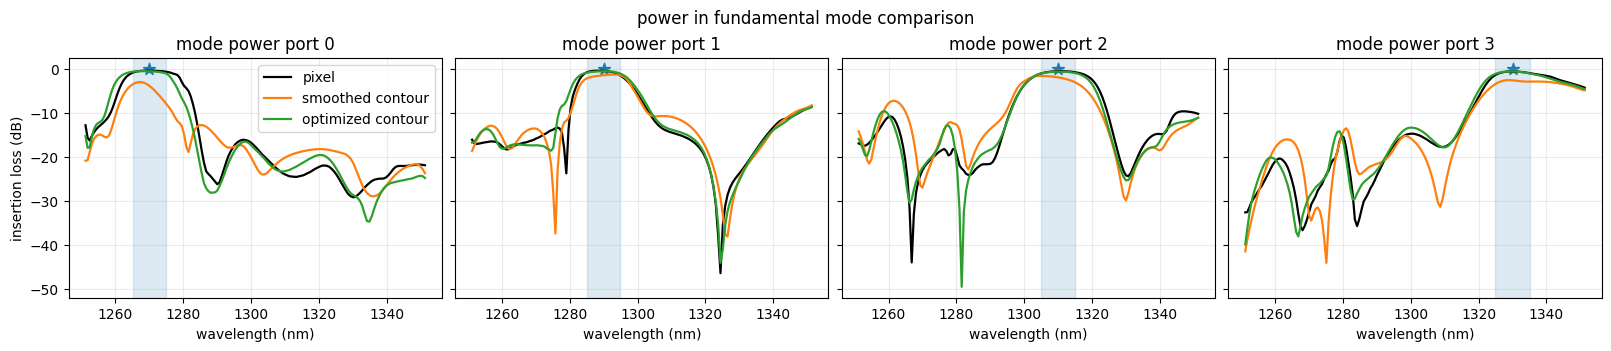

In [176]:
eval_pixel = run_dense_eval(pixel_design, task_name="wdm_eval_pixel")
eval_contour_smooth = run_dense_eval(contour_smooth_structures, task_name="wdm_eval_contour_smooth")
eval_contour_opt = run_dense_eval(contour_opt_structures, task_name="wdm_eval_contour_opt")

print("\n[dense transmission metric]")
print(f"pixel={eval_pixel['transmission']:.3f}")
print(f"smoothed contour={eval_contour_smooth['transmission']:.3f}")
print(f"optimized contour={eval_contour_opt['transmission']:.3f}")

names = ["pixel", "smoothed contour", "optimized contour"]
colors = ["black", "tab:orange", "tab:green"]
datasets = [eval_pixel, eval_contour_smooth, eval_contour_opt]

fig_flux, axes_flux = plt.subplots(
    1, num_freqs_design, figsize=(4.0 * num_freqs_design, 3.4), sharey=True, constrained_layout=True
)

for port, ax in enumerate(axes_flux):
    fmin, fmax = channel_bounds[port]
    wvl_min = 1000.0 * td.C_0 / fmax
    wvl_max = 1000.0 * td.C_0 / fmin
    target_wvl = 1000.0 * td.C_0 / freqs_design[port]

    ax.axvspan(wvl_min, wvl_max, color="tab:blue", alpha=0.15)
    for name, color, ds in zip(names, colors, datasets):
        ax.plot(ds["wavelength_nm"], ds["flux_db"][port], color=color, linewidth=1.6, label=name)

    ax.scatter([target_wvl], [0.0], marker="*", s=80, color="tab:blue")
    ax.set_title(f"flux port {port}")
    ax.set_xlabel("wavelength (nm)")
    ax.grid(alpha=0.25)
    if port == 0:
        ax.set_ylabel("insertion loss (dB)")
        ax.legend(loc="best")

fig_flux.suptitle("total flux comparison")
plt.show()

fig_power, axes_power = plt.subplots(
    1, num_freqs_design, figsize=(4.0 * num_freqs_design, 3.4), sharey=True, constrained_layout=True
)

for port, ax in enumerate(axes_power):
    fmin, fmax = channel_bounds[port]
    wvl_min = 1000.0 * td.C_0 / fmax
    wvl_max = 1000.0 * td.C_0 / fmin
    target_wvl = 1000.0 * td.C_0 / freqs_design[port]

    ax.axvspan(wvl_min, wvl_max, color="tab:blue", alpha=0.15)
    for name, color, ds in zip(names, colors, datasets):
        ax.plot(ds["wavelength_nm"], ds["power_db"][port], color=color, linewidth=1.6, label=name)

    ax.scatter([target_wvl], [0.0], marker="*", s=80, color="tab:blue")
    ax.set_title(f"mode power port {port}")
    ax.set_xlabel("wavelength (nm)")
    ax.grid(alpha=0.25)
    if port == 0:
        ax.set_ylabel("insertion loss (dB)")
        ax.legend(loc="best")

fig_power.suptitle("power in fundamental mode comparison")
plt.show()

### Fields
Finally, we inspect the field intensity patterns at the four design wavelengths for the
optimized contour geometry.

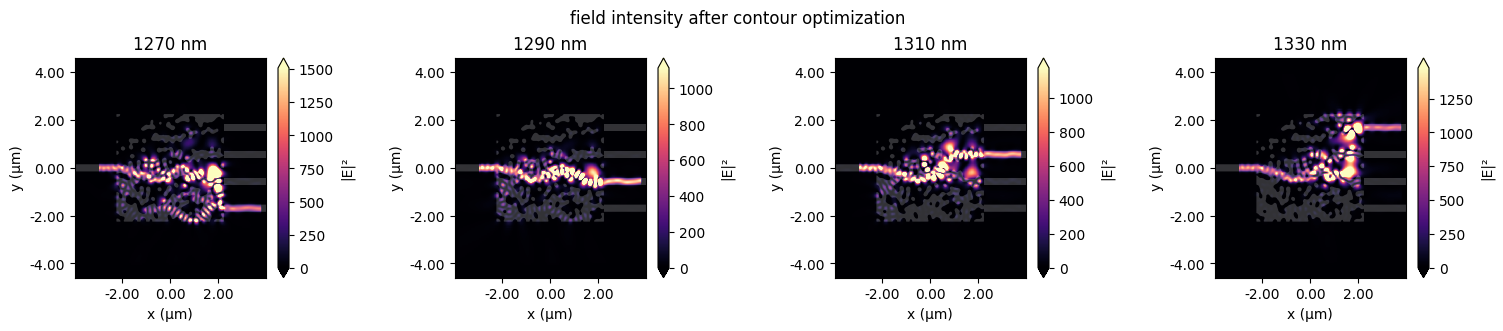

In [177]:
fig_fields, axes_fields = plt.subplots(
    1, num_freqs_design, figsize=(3.8 * num_freqs_design, 3.2), constrained_layout=True
)

for freq, ax in zip(freqs_design, axes_fields):
    eval_contour_opt["sim_data"].plot_field("field", "E", "abs^2", f=float(freq), ax=ax)
    wvl_nm = 1000.0 * td.C_0 / float(freq)
    ax.set_title(f"{round(wvl_nm)} nm")

fig_fields.suptitle("field intensity after contour optimization")
plt.show()

## Export Optimized Contour to GDS
Finally, we export the optimized contour geometry to GDS so it can be inspected or passed
to downstream layout checks. The export uses the same cross section and permittivity
threshold as the baseline GDS conversion.


In [178]:
gds_export_dir = Path("misc")
gds_export_dir.mkdir(parents=True, exist_ok=True)
contour_opt_gds_path = gds_export_dir / "wdm_contour_optimized.gds"

contour_opt_gds_sim = sim_static.updated_copy(
    structures=[*sim_static.structures, *contour_opt_structures],
    monitors=[],
)
contour_opt_gds_sim.to_gds_file(
    fname=str(contour_opt_gds_path),
    z=0.0,
    permittivity_threshold=permittivity_threshold,
    frequency=freq0,
)

print(f"exported optimized contour GDS to {contour_opt_gds_path}")

exported optimized contour GDS to misc/wdm_contour_optimized.gds


## Conclusion
This workflow starts from a saved topology optimized pixel design, quantifies the loss from
GDS conversion and contour smoothing, and then recovers part of that loss by optimizing the
smoothed contour directly. The final dense spectral analysis compares both total flux and
fundamental mode power, while the GDS export provides the optimized contour layout for
downstream fabrication oriented checks.
